In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root / "src"))

In [6]:
import pandas as pd

from pangya_physics import CLUBS, Wind, find_power

In [7]:
club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

distancias = [50, 100, 150, 200, 250, 300]

resultados = []

for distancia in distancias:
    result = find_power(
        club=club,
        wind=wind,
        target_distance=distancia,
    )

    resultados.append({
        "Distância Alvo": distancia,
        "Power %": round(result.power_percent * 100, 2),
        "Distância Final": round(result.final_distance, 2),
        "Erro": round(result.error, 2),
        "Iterações": result.iterations,
    })

df = pd.DataFrame(resultados)

df

,Distância Alvo,Power %,Distância Final,Erro,Iterações
0,50,32.09,50.01,-0.01,11
1,100,46.50,100.01,-0.01,11
2,150,58.82,150.88,-0.88,60
3,200,70.12,200.69,-0.69,60
4,250,80.98,250.20,-0.20,60
5,300,92.21,299.96,0.04,11


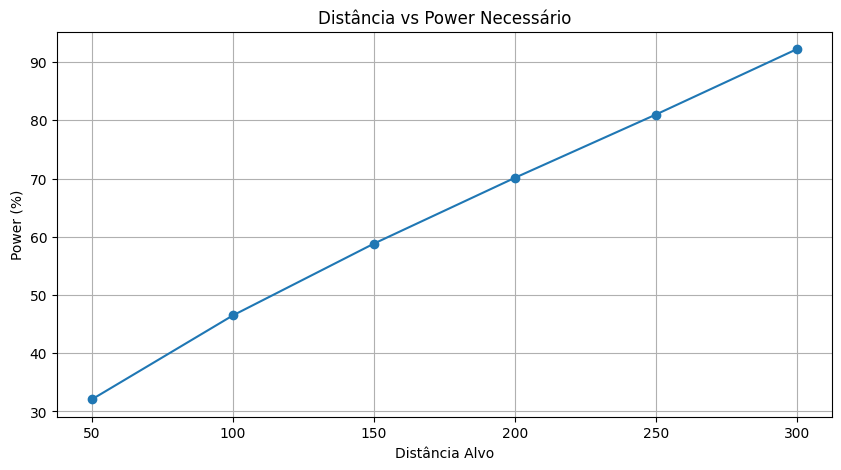

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df["Distância Alvo"],
    df["Power %"],
    marker="o",
)

plt.xlabel("Distância Alvo")
plt.ylabel("Power (%)")
plt.title("Distância vs Power Necessário")

plt.grid(True)

plt.show()